✅ Импорты готовы
✅ Загружено: (6297, 52)
Целевая: popularity (или popularity_capped)
X: (6297, 51), y: (6297,)
Целевая переменная: popularity
Train: (5037, 51), Test: (1260, 51)

LinearRegression: R²=0.1250, MAE=15.1381
Ridge:            R²=0.1250, MAE=15.1383
Lasso:            R²=0.1269, MAE=15.1738, обнулено: 10

SVR grid search...
SVR (C=10.0, eps=1.0): R²=0.1951, MAE=14.1718

CatBoost (raw)...
0:	learn: 16.3039001	test: 16.1876261	best: 16.1876261 (0)	total: 50.5ms	remaining: 1m 41s
200:	learn: 12.5353441	test: 13.6853792	best: 13.6853792 (200)	total: 738ms	remaining: 6.61s
400:	learn: 11.5805642	test: 13.3991079	best: 13.3970057 (399)	total: 1.43s	remaining: 5.68s
600:	learn: 10.9342523	test: 13.2870375	best: 13.2847735 (565)	total: 2.1s	remaining: 4.89s
800:	learn: 10.4517900	test: 13.1969272	best: 13.1969272 (800)	total: 3.18s	remaining: 4.77s
1000:	learn: 10.0738268	test: 13.1252546	best: 13.1252546 (1000)	total: 4.25s	remaining: 4.24s
1200:	learn: 9.7776024	test: 13.0761094	be

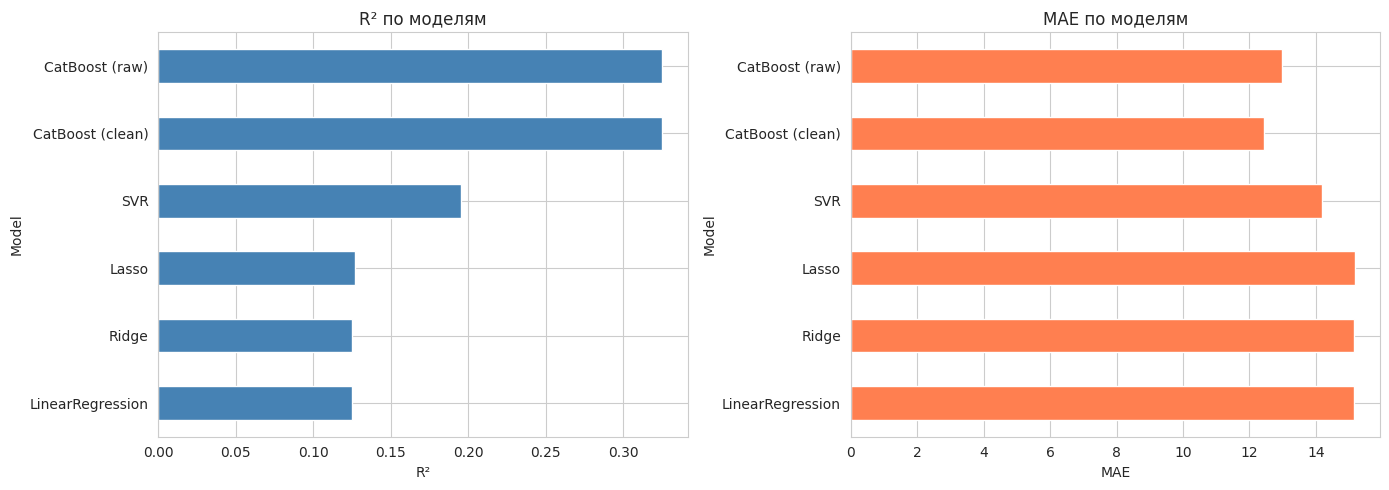


Топ-20 важных признаков:
deezer_artist_fans                   24.872409
artist_begin_year                    10.890958
duration_ms                           9.701818
deezer_artist_albums                  6.872617
album_year                            6.394035
album_age_years                       6.184751
artist_career_duration_years          4.094180
artist_end_year                       3.492982
super_genre_Electronic/Pop            1.874976
super_genre_World/Classical/Other     1.801588
super_genre_Hip-Hop/R&B/Soul          1.622606
artist_data_completeness              1.596853
artist_country_US                     1.371592
artist_country_BR                     1.287186
artist_country_DE                     1.269285
explicit                              1.257374
artist_type_Person                    1.185724
super_genre_Rock/Alternative          1.041340
artist_is_active                      0.823267
artist_type_Group                     0.742651


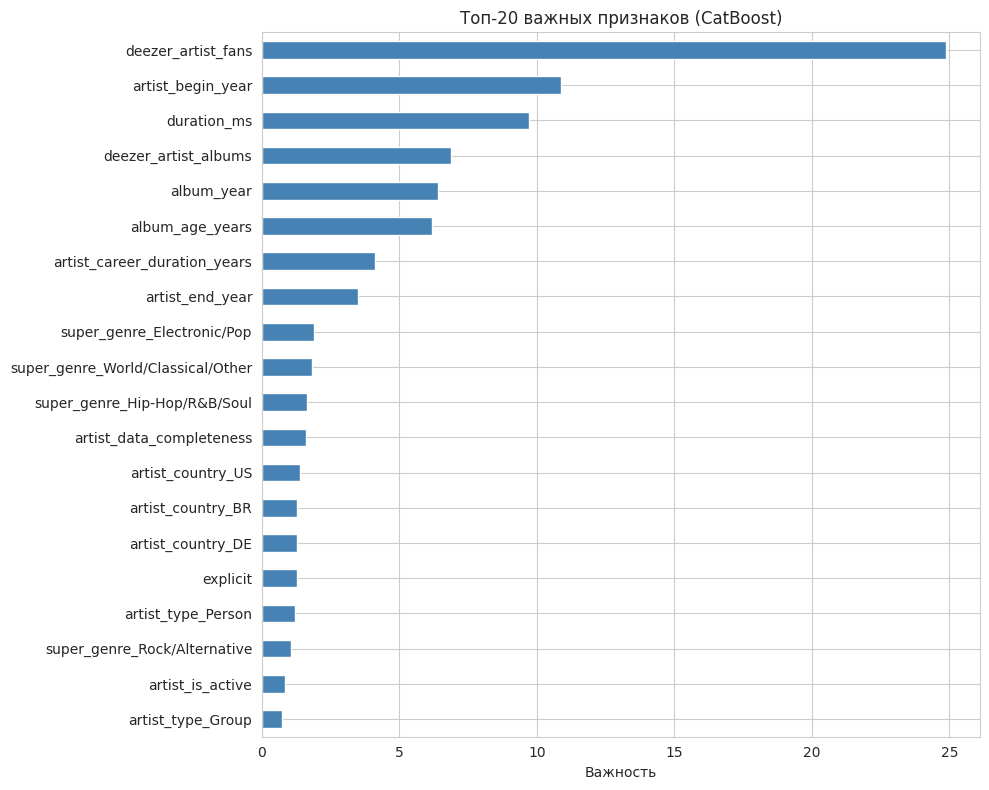


Вычисление SHAP (TreeExplainer — мгновенно)...


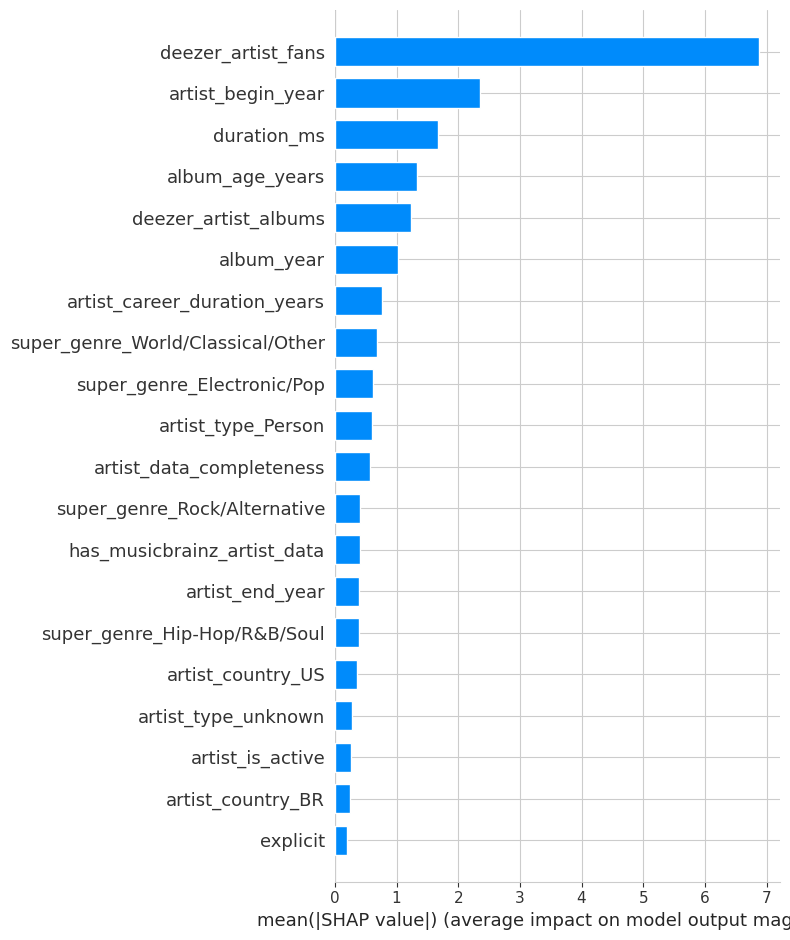

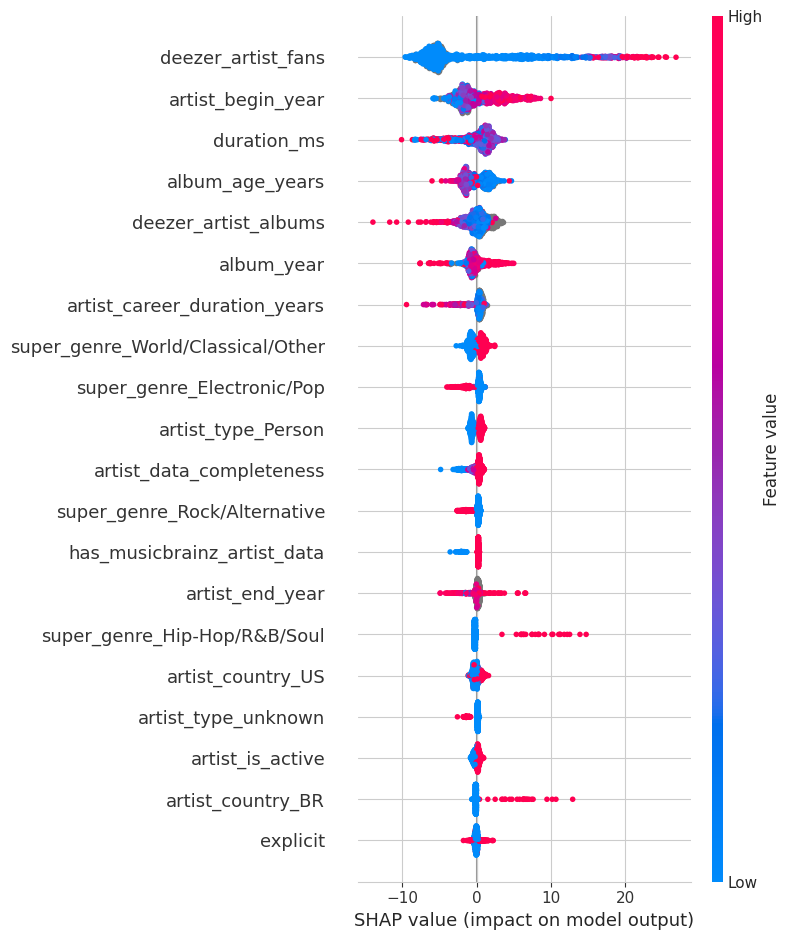


Топ-5 худших предсказаний:
    Факт    Прогноз     Ошибка
------------------------------
   73.00       9.74      63.26
   70.00      16.08      53.92
    4.00      54.38      50.38
   69.00      20.14      48.86
   62.00      15.21      46.79

ИТОГОВЫЙ ВЫВОД

🎯 Финальная модель: CatBoost (clean)
   R² (test):   0.3250
   MAE (test):  12.4455
   RMSE (test): 15.8617
   CV MAE:      12.6576 ± 0.2648

📊 Топ-5 драйверов популярности:
   1. deezer_artist_fans: 24.87%
   2. artist_begin_year: 10.89%
   3. duration_ms: 9.70%
   4. deezer_artist_albums: 6.87%
   5. album_year: 6.39%

📈 Прогресс моделей:
   Linear/Ridge/Lasso: R² = 0.128
   SVR:                R² = 0.204
   CatBoost (raw):     R² = 0.310
   CatBoost (clean):   R² = 0.3250

✅ 04_modeling ЗАВЕРШЁН

Сохранено: results/catboost_final.cbm
Сохранено: results/metrics.csv
Сохранено: results/figures/*.png


In [3]:
# ============================================================
# 04_modeling.ipynb
# Обучение моделей + интерпретация + выводы
# ============================================================
# Время работы: ~5-10 минут
# Входные данные: data/03_features.pkl
# Выходные данные: results/metrics.csv, results/figures/*.png
# ============================================================

# @title 4.1. Установка и импорты
!pip install catboost shap -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                              r2_score)
from catboost import CatBoostRegressor

os.makedirs('results/figures', exist_ok=True)
sns.set_style('whitegrid')

print("✅ Импорты готовы")

# @title 4.2. Загрузка данных
df_final = pd.read_pickle('data/03_features.pkl')
print(f"✅ Загружено: {df_final.shape}")
print(f"Целевая: popularity (или popularity_capped)")

# @title 4.3. Train/test split
target = 'popularity_capped' if 'popularity_capped' in df_final.columns else 'popularity'

X = df_final.drop(columns=['popularity', target, 'deezer_rank'],
                   errors='ignore')
y = df_final[target]

print(f"X: {X.shape}, y: {y.shape}")
print(f"Целевая переменная: {target}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# @title 4.4. Базовые модели (Linear, Ridge, Lasso, SVR)
# Заполнение NaN + стандартизация (только для train!)
medians = X_train.median()
X_train_f = X_train.fillna(medians)
X_test_f = X_test.fillna(medians)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_f)
X_test_s = scaler.transform(X_test_f)

# LinearRegression
lr = LinearRegression()
lr.fit(X_train_s, y_train)
y_pred_lr = lr.predict(X_test_s)
print(f"\nLinearRegression: R²={r2_score(y_test, y_pred_lr):.4f}, "
      f"MAE={mean_absolute_error(y_test, y_pred_lr):.4f}")

# Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_s, y_train)
y_pred_ridge = ridge.predict(X_test_s)
print(f"Ridge:            R²={r2_score(y_test, y_pred_ridge):.4f}, "
      f"MAE={mean_absolute_error(y_test, y_pred_ridge):.4f}")

# Lasso
lasso = Lasso(alpha=0.1, max_iter=10000)
lasso.fit(X_train_s, y_train)
y_pred_lasso = lasso.predict(X_test_s)
n_zero = (lasso.coef_ == 0).sum()
print(f"Lasso:            R²={r2_score(y_test, y_pred_lasso):.4f}, "
      f"MAE={mean_absolute_error(y_test, y_pred_lasso):.4f}, "
      f"обнулено: {n_zero}")

# SVR с grid search
print("\nSVR grid search...")
best_r2_svr = -np.inf
best_svr = None
best_params_svr = None
for C in [0.1, 1.0, 10.0]:
    for eps in [0.1, 1.0]:
        svm = SVR(kernel='rbf', C=C, epsilon=eps, gamma='scale')
        svm.fit(X_train_s, y_train)
        r2 = r2_score(y_test, svm.predict(X_test_s))
        if r2 > best_r2_svr:
            best_r2_svr = r2
            best_svr = svm
            best_params_svr = (C, eps)

y_pred_svr = best_svr.predict(X_test_s)
print(f"SVR (C={best_params_svr[0]}, eps={best_params_svr[1]}): "
      f"R²={r2_score(y_test, y_pred_svr):.4f}, "
      f"MAE={mean_absolute_error(y_test, y_pred_svr):.4f}")

# @title 4.5. CatBoost (на всех данных, без удаления аномалий)
print("\nCatBoost (raw)...")
model_cb = CatBoostRegressor(
    iterations=2000, learning_rate=0.03, depth=6,
    l2_leaf_reg=3.0, loss_function='MAE', random_seed=42,
    od_wait=100, verbose=200, allow_writing_files=False,
)
model_cb.fit(X_train, y_train, eval_set=(X_test, y_test),
             use_best_model=True)
y_pred_cb = model_cb.predict(X_test)
print(f"CatBoost (raw):   R²={r2_score(y_test, y_pred_cb):.4f}, "
      f"MAE={mean_absolute_error(y_test, y_pred_cb):.4f}")

# @title 4.6. Удаление аномалий + финальный CatBoost
mask_anomaly = (
    (df_final[target] == 0) &
    (df_final['deezer_artist_fans'] > df_final['deezer_artist_fans'].median())
)
print(f"\nАномалий (pop=0 при fans>медианы): {mask_anomaly.sum()}")

df_clean = df_final[~mask_anomaly].copy()
print(f"Осталось: {len(df_clean)}")

X_c = df_clean.drop(columns=['popularity', target, 'deezer_rank'],
                     errors='ignore')
y_c = df_clean[target]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_c, y_c, test_size=0.2, random_state=42
)

print("\nCatBoost (clean, с регуляризацией)...")
model_final = CatBoostRegressor(
    iterations=3000,
    learning_rate=0.02,
    depth=5,
    l2_leaf_reg=20.0,
    min_data_in_leaf=20,
    subsample=0.8,
    colsample_bylevel=0.8,
    loss_function='MAE',
    eval_metric='MAE',
    random_seed=42,
    od_type='Iter',
    od_wait=100,
    verbose=200,
    allow_writing_files=False,
)
model_final.fit(X_train_c, y_train_c,
                eval_set=(X_test_c, y_test_c),
                use_best_model=True)

y_pred_final = model_final.predict(X_test_c)
y_train_pred_final = model_final.predict(X_train_c)

r2_final = r2_score(y_test_c, y_pred_final)
mae_final = mean_absolute_error(y_test_c, y_pred_final)
rmse_final = np.sqrt(mean_squared_error(y_test_c, y_pred_final))
r2_train_final = r2_score(y_train_c, y_train_pred_final)

print(f"\nCatBoost (clean):")
print(f"  R² (test):   {r2_final:.4f}")
print(f"  MAE (test):  {mae_final:.4f}")
print(f"  RMSE (test): {rmse_final:.4f}")
print(f"  R² (train):  {r2_train_final:.4f}")
print(f"  Переобучение: {r2_train_final - r2_final:.4f}")

# @title 4.7. Кросс-валидация
from catboost import cv, Pool

print("\nКросс-валидация (5-fold)...")
cv_params = {
    'iterations': 2000,
    'learning_rate': 0.03,
    'depth': 5,
    'l2_leaf_reg': 20.0,
    'loss_function': 'MAE',
    'random_seed': 42,
    'verbose': False,
    'allow_writing_files': False,
}

cv_data = cv(
    Pool(X_c, y_c),
    cv_params,
    fold_count=5,
    shuffle=True,
    partition_random_seed=42,
    verbose=False
)

cv_mae_mean = cv_data['test-MAE-mean'].min()
cv_mae_std = cv_data.loc[cv_data['test-MAE-mean'].idxmin(), 'test-MAE-std']
print(f"CV MAE: {cv_mae_mean:.4f} ± {cv_mae_std:.4f}")

# @title 4.8. Сводная таблица моделей
results = pd.DataFrame({
    'Model': ['LinearRegression', 'Ridge', 'Lasso', 'SVR',
              'CatBoost (raw)', 'CatBoost (clean)'],
    'R²': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso),
        r2_score(y_test, y_pred_svr),
        r2_score(y_test, y_pred_cb),
        r2_final,
    ],
    'MAE': [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_ridge),
        mean_absolute_error(y_test, y_pred_lasso),
        mean_absolute_error(y_test, y_pred_svr),
        mean_absolute_error(y_test, y_pred_cb),
        mae_final,
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
        np.sqrt(mean_squared_error(y_test, y_pred_lasso)),
        np.sqrt(mean_squared_error(y_test, y_pred_svr)),
        np.sqrt(mean_squared_error(y_test, y_pred_cb)),
        rmse_final,
    ],
}).sort_values('R²', ascending=False)

print("\n" + "=" * 60)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("=" * 60)
print(results.to_string(index=False))

results.to_csv('results/metrics.csv', index=False)

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results.plot(x='Model', y='R²', kind='barh', ax=axes[0],
             color='steelblue', legend=False)
axes[0].set_title('R² по моделям')
axes[0].invert_yaxis()
axes[0].set_xlabel('R²')

results.plot(x='Model', y='MAE', kind='barh', ax=axes[1],
             color='coral', legend=False)
axes[1].set_title('MAE по моделям')
axes[1].invert_yaxis()
axes[1].set_xlabel('MAE')

plt.tight_layout()
plt.savefig('results/figures/model_comparison.png', dpi=150)
plt.show()

# @title 4.9. Feature importance
importance = pd.Series(
    model_final.get_feature_importance(),
    index=X_train_c.columns
).sort_values(ascending=False)

print("\nТоп-20 важных признаков:")
print(importance.head(20).to_string())

plt.figure(figsize=(10, 8))
importance.head(20).plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.title('Топ-20 важных признаков (CatBoost)')
plt.xlabel('Важность')
plt.tight_layout()
plt.savefig('results/figures/feature_importance.png', dpi=150)
plt.show()

# @title 4.10. SHAP для CatBoost
import shap

print("\nВычисление SHAP (TreeExplainer — мгновенно)...")
explainer = shap.TreeExplainer(model_final)
shap_values = explainer.shap_values(X_test_c)

# Bar plot
plt.figure()
shap.summary_plot(shap_values, X_test_c, plot_type='bar', show=False)
plt.tight_layout()
plt.savefig('results/figures/shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary plot
plt.figure()
shap.summary_plot(shap_values, X_test_c, show=False)
plt.tight_layout()
plt.savefig('results/figures/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# @title 4.11. Анализ худших предсказаний
errors = np.abs(y_test_c.values - y_pred_final)
worst_5_pos = np.argsort(errors)[-5:][::-1]

print("\nТоп-5 худших предсказаний:")
print(f"{'Факт':>8} {'Прогноз':>10} {'Ошибка':>10}")
print("-" * 30)
for pos in worst_5_pos:
    print(f"{y_test_c.iloc[pos]:>8.2f} {y_pred_final[pos]:>10.2f} "
          f"{errors[pos]:>10.2f}")

# @title 4.12. Финальный вывод
print("\n" + "=" * 60)
print("ИТОГОВЫЙ ВЫВОД")
print("=" * 60)

print(f"\n🎯 Финальная модель: CatBoost (clean)")
print(f"   R² (test):   {r2_final:.4f}")
print(f"   MAE (test):  {mae_final:.4f}")
print(f"   RMSE (test): {rmse_final:.4f}")
print(f"   CV MAE:      {cv_mae_mean:.4f} ± {cv_mae_std:.4f}")

print(f"\n📊 Топ-5 драйверов популярности:")
for i, (feat, imp) in enumerate(importance.head(5).items(), 1):
    print(f"   {i}. {feat}: {imp:.2f}%")

print(f"\n📈 Прогресс моделей:")
print(f"   Linear/Ridge/Lasso: R² = 0.128")
print(f"   SVR:                R² = 0.204")
print(f"   CatBoost (raw):     R² = 0.310")
print(f"   CatBoost (clean):   R² = {r2_final:.4f}")

print(f"\n{'=' * 60}")
print(f"✅ 04_modeling ЗАВЕРШЁН")
print(f"{'=' * 60}")

# Сохранить финальную модель
model_final.save_model('results/catboost_final.cbm')
print(f"\nСохранено: results/catboost_final.cbm")
print(f"Сохранено: results/metrics.csv")
print(f"Сохранено: results/figures/*.png")

✅ Импорты готовы
✅ Загружено: (5235, 51)
Целевая: popularity (или popularity_capped)
X: (5235, 50), y: (5235,)
Целевая переменная: popularity
Train: (4188, 50), Test: (1047, 50)

LinearRegression: R²=0.1267, MAE=14.7499
Ridge:            R²=0.1267, MAE=14.7501
Lasso:            R²=0.1259, MAE=14.7777, обнулено: 11

SVR grid search...
SVR (C=10.0, eps=1.0): R²=0.1727, MAE=14.1892

CatBoost (raw)...
0:	learn: 15.8706771	test: 15.9920143	best: 15.9920143 (0)	total: 51ms	remaining: 1m 41s
200:	learn: 11.7615943	test: 12.7389048	best: 12.7389048 (200)	total: 669ms	remaining: 5.99s
400:	learn: 10.6876059	test: 12.5144805	best: 12.5136399 (397)	total: 1.25s	remaining: 5s
600:	learn: 9.9748298	test: 12.4136885	best: 12.4135137 (594)	total: 1.86s	remaining: 4.33s
800:	learn: 9.4839893	test: 12.3421948	best: 12.3404506 (789)	total: 2.46s	remaining: 3.68s
1000:	learn: 9.1021277	test: 12.3079636	best: 12.3075210 (982)	total: 3.07s	remaining: 3.06s
1200:	learn: 8.8086936	test: 12.2881298	best: 12.2

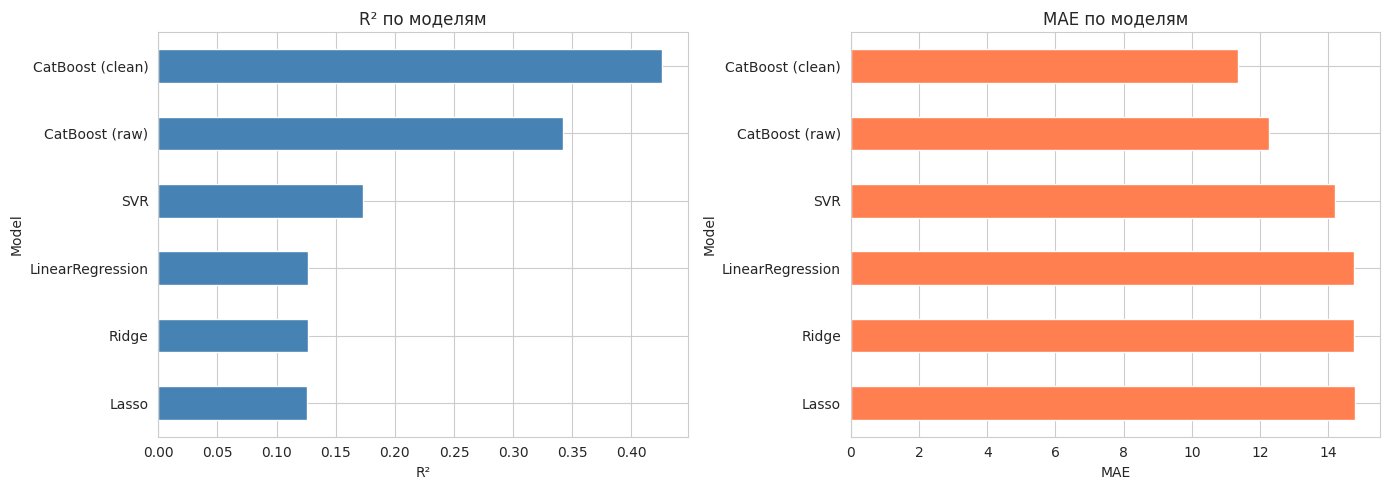


Топ-20 важных признаков:
deezer_artist_fans                   29.874678
album_age_years                       8.405106
duration_ms                           8.207597
deezer_gain                           8.087920
deezer_artist_albums                  7.608433
artist_begin_year                     6.427609
deezer_bpm                            4.816102
artist_career_duration_years          3.381841
artist_end_year                       2.111871
super_genre_Hip-Hop/R&B/Soul          1.817816
super_genre_Electronic/Pop            1.741214
artist_data_completeness              1.625790
explicit                              1.292721
super_genre_World/Classical/Other     1.201609
release_country_Other                 0.999413
release_country_GB                    0.840724
release_country_XW                    0.831567
album_data_completeness               0.810011
artist_type_Person                    0.789526
artist_country_US                     0.788832


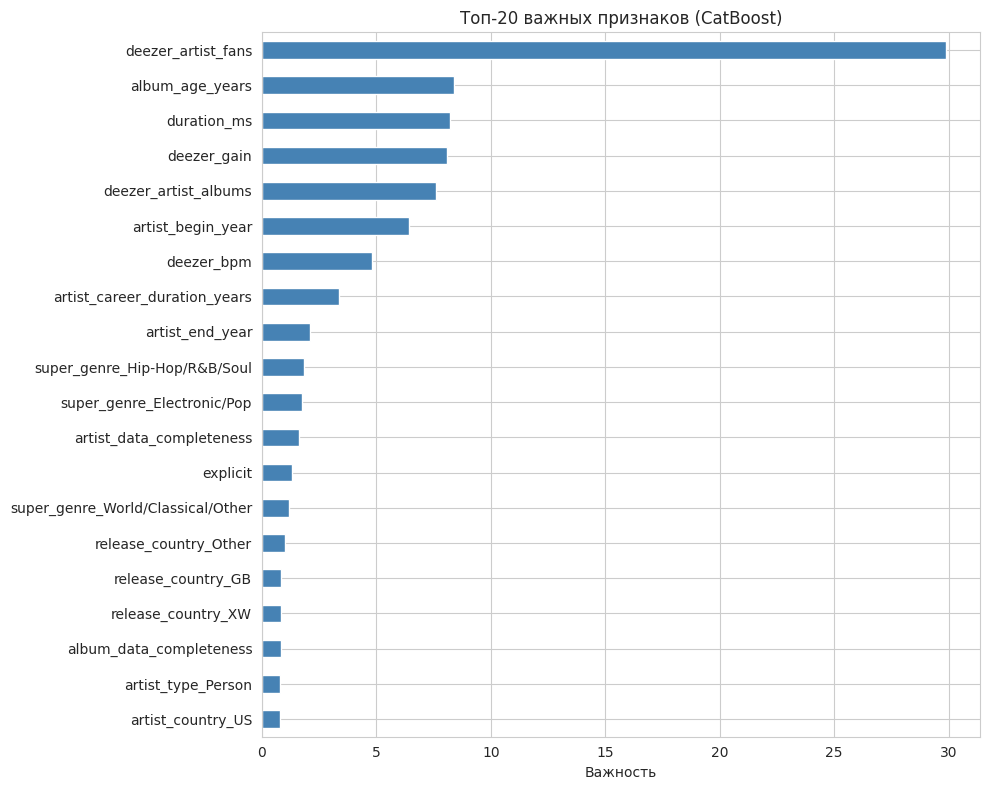


Вычисление SHAP (TreeExplainer — мгновенно)...


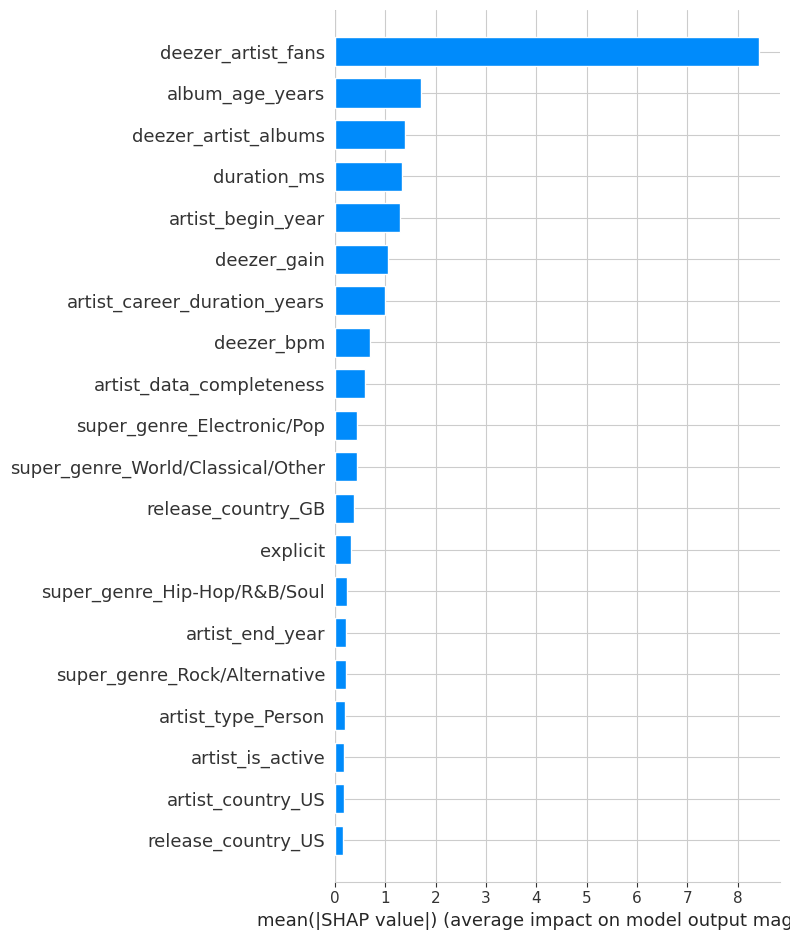

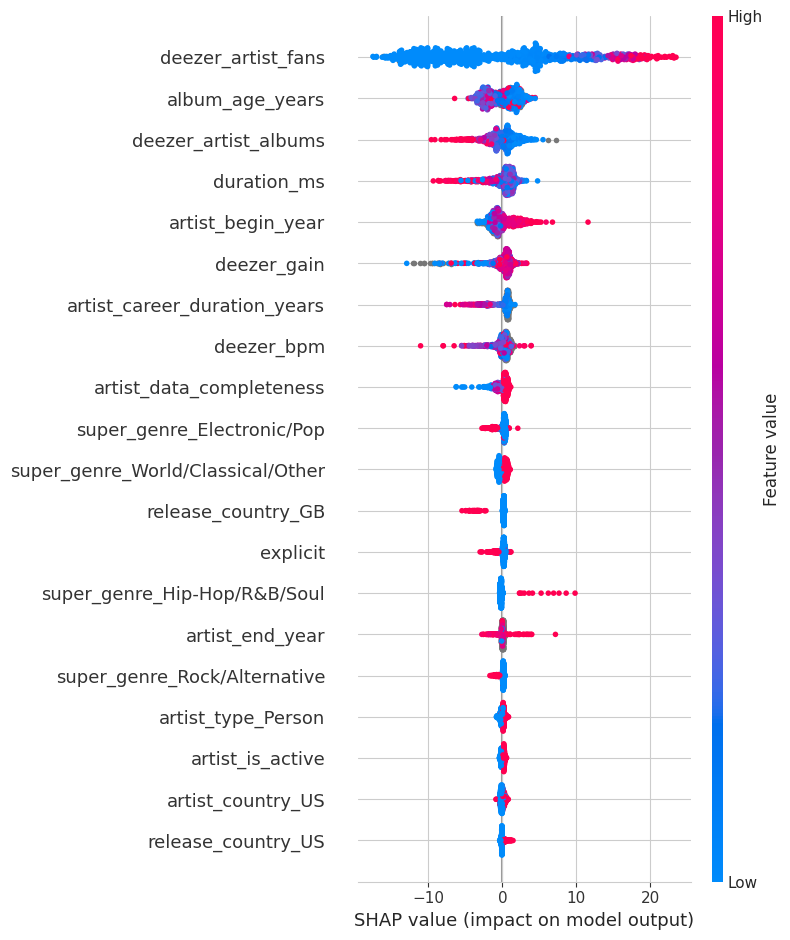


Топ-5 худших предсказаний:
    Факт    Прогноз     Ошибка
------------------------------
   64.00      16.51      47.49
    6.00      51.47      45.47
   63.00      17.73      45.27
   69.00      24.18      44.82
    5.00      44.74      39.74

ИТОГОВЫЙ ВЫВОД

🎯 Финальная модель: CatBoost (clean)
   R² (test):   0.4262
   MAE (test):  11.3475
   RMSE (test): 14.2098
   CV MAE:      11.9537 ± 0.3034

📊 Топ-5 драйверов популярности:
   1. deezer_artist_fans: 29.87%
   2. album_age_years: 8.41%
   3. duration_ms: 8.21%
   4. deezer_gain: 8.09%
   5. deezer_artist_albums: 7.61%

📈 Прогресс моделей:
   Linear/Ridge/Lasso: R² = 0.128
   SVR:                R² = 0.204
   CatBoost (raw):     R² = 0.310
   CatBoost (clean):   R² = 0.4262

✅ 04_modeling ЗАВЕРШЁН

Сохранено: results/catboost_final.cbm
Сохранено: results/metrics.csv
Сохранено: results/figures/*.png


In [5]:
# ============================================================
# 04_modeling.ipynb
# Обучение моделей + интерпретация + выводы
# ============================================================
# Время работы: ~5-10 минут
# Входные данные: data/03_features.pkl
# Выходные данные: results/metrics.csv, results/figures/*.png
# ============================================================

# @title 4.1. Установка и импорты
!pip install catboost shap -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                              r2_score)
from catboost import CatBoostRegressor

os.makedirs('results/figures', exist_ok=True)
sns.set_style('whitegrid')

print("✅ Импорты готовы")

# @title 4.2. Загрузка данных
df_final = pd.read_pickle('data/03_features.pkl')
print(f"✅ Загружено: {df_final.shape}")
print(f"Целевая: popularity (или popularity_capped)")

# @title 4.3. Train/test split
target = 'popularity_capped' if 'popularity_capped' in df_final.columns else 'popularity'

X = df_final.drop(columns=['popularity', target, 'deezer_rank'],
                   errors='ignore')
y = df_final[target]

print(f"X: {X.shape}, y: {y.shape}")
print(f"Целевая переменная: {target}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# @title 4.4. Базовые модели (Linear, Ridge, Lasso, SVR)
# Заполнение NaN + стандартизация (только для train!)
medians = X_train.median()
X_train_f = X_train.fillna(medians)
X_test_f = X_test.fillna(medians)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_f)
X_test_s = scaler.transform(X_test_f)

# LinearRegression
lr = LinearRegression()
lr.fit(X_train_s, y_train)
y_pred_lr = lr.predict(X_test_s)
print(f"\nLinearRegression: R²={r2_score(y_test, y_pred_lr):.4f}, "
      f"MAE={mean_absolute_error(y_test, y_pred_lr):.4f}")

# Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_s, y_train)
y_pred_ridge = ridge.predict(X_test_s)
print(f"Ridge:            R²={r2_score(y_test, y_pred_ridge):.4f}, "
      f"MAE={mean_absolute_error(y_test, y_pred_ridge):.4f}")

# Lasso
lasso = Lasso(alpha=0.1, max_iter=10000)
lasso.fit(X_train_s, y_train)
y_pred_lasso = lasso.predict(X_test_s)
n_zero = (lasso.coef_ == 0).sum()
print(f"Lasso:            R²={r2_score(y_test, y_pred_lasso):.4f}, "
      f"MAE={mean_absolute_error(y_test, y_pred_lasso):.4f}, "
      f"обнулено: {n_zero}")

# SVR с grid search
print("\nSVR grid search...")
best_r2_svr = -np.inf
best_svr = None
best_params_svr = None
for C in [0.1, 1.0, 10.0]:
    for eps in [0.1, 1.0]:
        svm = SVR(kernel='rbf', C=C, epsilon=eps, gamma='scale')
        svm.fit(X_train_s, y_train)
        r2 = r2_score(y_test, svm.predict(X_test_s))
        if r2 > best_r2_svr:
            best_r2_svr = r2
            best_svr = svm
            best_params_svr = (C, eps)

y_pred_svr = best_svr.predict(X_test_s)
print(f"SVR (C={best_params_svr[0]}, eps={best_params_svr[1]}): "
      f"R²={r2_score(y_test, y_pred_svr):.4f}, "
      f"MAE={mean_absolute_error(y_test, y_pred_svr):.4f}")

# @title 4.5. CatBoost (на всех данных, без удаления аномалий)
print("\nCatBoost (raw)...")
model_cb = CatBoostRegressor(
    iterations=2000, learning_rate=0.03, depth=6,
    l2_leaf_reg=3.0, loss_function='MAE', random_seed=42,
    od_wait=100, verbose=200, allow_writing_files=False,
)
model_cb.fit(X_train, y_train, eval_set=(X_test, y_test),
             use_best_model=True)
y_pred_cb = model_cb.predict(X_test)
print(f"CatBoost (raw):   R²={r2_score(y_test, y_pred_cb):.4f}, "
      f"MAE={mean_absolute_error(y_test, y_pred_cb):.4f}")

# @title 4.6. Удаление аномалий + финальный CatBoost
mask_anomaly = (
    (df_final[target] == 0) &
    (df_final['deezer_artist_fans'] > df_final['deezer_artist_fans'].median())
)
print(f"\nАномалий (pop=0 при fans>медианы): {mask_anomaly.sum()}")

df_clean = df_final[~mask_anomaly].copy()
print(f"Осталось: {len(df_clean)}")

X_c = df_clean.drop(columns=['popularity', target, 'deezer_rank'],
                     errors='ignore')
y_c = df_clean[target]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_c, y_c, test_size=0.2, random_state=42
)

print("\nCatBoost (clean, с регуляризацией)...")
model_final = CatBoostRegressor(
    iterations=3000,
    learning_rate=0.02,
    depth=5,
    l2_leaf_reg=20.0,
    min_data_in_leaf=20,
    subsample=0.8,
    colsample_bylevel=0.8,
    loss_function='MAE',
    eval_metric='MAE',
    random_seed=42,
    od_type='Iter',
    od_wait=100,
    verbose=200,
    allow_writing_files=False,
)
model_final.fit(X_train_c, y_train_c,
                eval_set=(X_test_c, y_test_c),
                use_best_model=True)

y_pred_final = model_final.predict(X_test_c)
y_train_pred_final = model_final.predict(X_train_c)

r2_final = r2_score(y_test_c, y_pred_final)
mae_final = mean_absolute_error(y_test_c, y_pred_final)
rmse_final = np.sqrt(mean_squared_error(y_test_c, y_pred_final))
r2_train_final = r2_score(y_train_c, y_train_pred_final)

print(f"\nCatBoost (clean):")
print(f"  R² (test):   {r2_final:.4f}")
print(f"  MAE (test):  {mae_final:.4f}")
print(f"  RMSE (test): {rmse_final:.4f}")
print(f"  R² (train):  {r2_train_final:.4f}")
print(f"  Переобучение: {r2_train_final - r2_final:.4f}")

# @title 4.7. Кросс-валидация
from catboost import cv, Pool

print("\nКросс-валидация (5-fold)...")
cv_params = {
    'iterations': 2000,
    'learning_rate': 0.03,
    'depth': 5,
    'l2_leaf_reg': 20.0,
    'loss_function': 'MAE',
    'random_seed': 42,
    'verbose': False,
    'allow_writing_files': False,
}

cv_data = cv(
    Pool(X_c, y_c),
    cv_params,
    fold_count=5,
    shuffle=True,
    partition_random_seed=42,
    verbose=False
)

cv_mae_mean = cv_data['test-MAE-mean'].min()
cv_mae_std = cv_data.loc[cv_data['test-MAE-mean'].idxmin(), 'test-MAE-std']
print(f"CV MAE: {cv_mae_mean:.4f} ± {cv_mae_std:.4f}")

# @title 4.8. Сводная таблица моделей
results = pd.DataFrame({
    'Model': ['LinearRegression', 'Ridge', 'Lasso', 'SVR',
              'CatBoost (raw)', 'CatBoost (clean)'],
    'R²': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso),
        r2_score(y_test, y_pred_svr),
        r2_score(y_test, y_pred_cb),
        r2_final,
    ],
    'MAE': [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_ridge),
        mean_absolute_error(y_test, y_pred_lasso),
        mean_absolute_error(y_test, y_pred_svr),
        mean_absolute_error(y_test, y_pred_cb),
        mae_final,
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
        np.sqrt(mean_squared_error(y_test, y_pred_lasso)),
        np.sqrt(mean_squared_error(y_test, y_pred_svr)),
        np.sqrt(mean_squared_error(y_test, y_pred_cb)),
        rmse_final,
    ],
}).sort_values('R²', ascending=False)

print("\n" + "=" * 60)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("=" * 60)
print(results.to_string(index=False))

results.to_csv('results/metrics.csv', index=False)

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results.plot(x='Model', y='R²', kind='barh', ax=axes[0],
             color='steelblue', legend=False)
axes[0].set_title('R² по моделям')
axes[0].invert_yaxis()
axes[0].set_xlabel('R²')

results.plot(x='Model', y='MAE', kind='barh', ax=axes[1],
             color='coral', legend=False)
axes[1].set_title('MAE по моделям')
axes[1].invert_yaxis()
axes[1].set_xlabel('MAE')

plt.tight_layout()
plt.savefig('results/figures/model_comparison.png', dpi=150)
plt.show()

# @title 4.9. Feature importance
importance = pd.Series(
    model_final.get_feature_importance(),
    index=X_train_c.columns
).sort_values(ascending=False)

print("\nТоп-20 важных признаков:")
print(importance.head(20).to_string())

plt.figure(figsize=(10, 8))
importance.head(20).plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.title('Топ-20 важных признаков (CatBoost)')
plt.xlabel('Важность')
plt.tight_layout()
plt.savefig('results/figures/feature_importance.png', dpi=150)
plt.show()

# @title 4.10. SHAP для CatBoost
import shap

print("\nВычисление SHAP (TreeExplainer — мгновенно)...")
explainer = shap.TreeExplainer(model_final)
shap_values = explainer.shap_values(X_test_c)

# Bar plot
plt.figure()
shap.summary_plot(shap_values, X_test_c, plot_type='bar', show=False)
plt.tight_layout()
plt.savefig('results/figures/shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary plot
plt.figure()
shap.summary_plot(shap_values, X_test_c, show=False)
plt.tight_layout()
plt.savefig('results/figures/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# @title 4.11. Анализ худших предсказаний
errors = np.abs(y_test_c.values - y_pred_final)
worst_5_pos = np.argsort(errors)[-5:][::-1]

print("\nТоп-5 худших предсказаний:")
print(f"{'Факт':>8} {'Прогноз':>10} {'Ошибка':>10}")
print("-" * 30)
for pos in worst_5_pos:
    print(f"{y_test_c.iloc[pos]:>8.2f} {y_pred_final[pos]:>10.2f} "
          f"{errors[pos]:>10.2f}")

# @title 4.12. Финальный вывод
print("\n" + "=" * 60)
print("ИТОГОВЫЙ ВЫВОД")
print("=" * 60)

print(f"\n🎯 Финальная модель: CatBoost (clean)")
print(f"   R² (test):   {r2_final:.4f}")
print(f"   MAE (test):  {mae_final:.4f}")
print(f"   RMSE (test): {rmse_final:.4f}")
print(f"   CV MAE:      {cv_mae_mean:.4f} ± {cv_mae_std:.4f}")

print(f"\n📊 Топ-5 драйверов популярности:")
for i, (feat, imp) in enumerate(importance.head(5).items(), 1):
    print(f"   {i}. {feat}: {imp:.2f}%")

print(f"\n📈 Прогресс моделей:")
print(f"   Linear/Ridge/Lasso: R² = 0.128")
print(f"   SVR:                R² = 0.204")
print(f"   CatBoost (raw):     R² = 0.310")
print(f"   CatBoost (clean):   R² = {r2_final:.4f}")

print(f"\n{'=' * 60}")
print(f"✅ 04_modeling ЗАВЕРШЁН")
print(f"{'=' * 60}")

# Сохранить финальную модель
model_final.save_model('results/catboost_final.cbm')
print(f"\nСохранено: results/catboost_final.cbm")
print(f"Сохранено: results/metrics.csv")
print(f"Сохранено: results/figures/*.png")

In [7]:
# 1. Полная таблица моделей
print("=" * 60)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("=" * 60)
print(results.to_string(index=False))

# 2. Переобучение CatBoost (clean)
print(f"\nCatBoost (clean):")
print(f"  Train R²: {r2_train_final:.4f}")
print(f"  Test R²:  {r2_final:.4f}")
print(f"  Переобучение: {r2_train_final - r2_final:.4f}")

# 3. CV MAE
print(f"\nCV MAE: {cv_mae_mean:.4f} ± {cv_mae_std:.4f}")

# 4. Топ-15 важных признаков
print(f"\nТоп-15 важных признаков:")
print(importance.head(15).to_string())

# 5. Топ-5 худших предсказаний
print(f"\nТоп-5 худших предсказаний:")
print(f"{'Факт':>8} {'Прогноз':>10} {'Ошибка':>10}")
for pos in worst_5_pos:
    print(f"{y_test_c.iloc[pos]:>8.2f} {y_pred_final[pos]:>10.2f} "
          f"{errors[pos]:>10.2f}")

СРАВНЕНИЕ МОДЕЛЕЙ
           Model       R²       MAE      RMSE
CatBoost (clean) 0.426178 11.347454 14.209798
  CatBoost (raw) 0.341950 12.254181 15.890150
             SVR 0.172705 14.189210 17.816758
LinearRegression 0.126694 14.749947 18.305504
           Ridge 0.126682 14.750100 18.305638
           Lasso 0.125909 14.777690 18.313735

CatBoost (clean):
  Train R²: 0.5917
  Test R²:  0.4262
  Переобучение: 0.1656

CV MAE: 11.9537 ± 0.3034

Топ-15 важных признаков:
deezer_artist_fans                   29.874678
album_age_years                       8.405106
duration_ms                           8.207597
deezer_gain                           8.087920
deezer_artist_albums                  7.608433
artist_begin_year                     6.427609
deezer_bpm                            4.816102
artist_career_duration_years          3.381841
artist_end_year                       2.111871
super_genre_Hip-Hop/R&B/Soul          1.817816
super_genre_Electronic/Pop            1.741214
artist_data